## Unsupervised Learning Trading Strategy

- Download/Load SP500 stocks prices data.
- Calculate different features and indicators on each stock.
- Aggregate on monthly level and filter top 150 most liquid stocks.
- Calculate Monthly Returns for different time-horizons.
- Download Fama-French Factors and Calculate Rolling Factor Betas.
- For each month fit a K-Means Clustering Algorithm to group similar assets based on their features.
- For each month select assets based on the cluster and form a portfolio based on Efficient Frontier max sharpe ratio optimization.
- Visualize Portfolio returns and compare to SP500 returns.


## All Packages Needed:
- pandas, numpy, matplotlib, statsmodels, pandas_datareader, datetime, yfinance, sklearn, PyPortfolioOpt

### 1. Download/Load SP500 stocks prices data.

In [1]:
from statsmodels.regression.rolling import RollingOLS
import io
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import pandas_ta
import warnings
warnings.filterwarnings('ignore')
import requests

In [2]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

response = requests.get(url, headers=headers, timeout=30)
response.raise_for_status()
tables = pd.read_html(io.StringIO(response.text))

sp500 = tables[0]

sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-', regex=False)

symbols_list = sp500['Symbol'].unique().tolist()

end_date = '2023-09-27'

start_date = pd.to_datetime(end_date)-pd.DateOffset(365*8)

df = yf.download(tickers=symbols_list,
                 start=start_date,
                 end=end_date).stack()

df.index.names = ['date', 'ticker']

df.columns = df.columns.str.lower()

if 'adj close' not in df.columns:
    df['adj close'] = df['close']
else:
    df['adj close'] = df['adj close'].fillna(df['close'])

df


[**************        30%                       ]  151 of 503 completed$VLTO: Data doesn't exist for startDate = 1443499200, endDate = 1695787200
[****************      34%                       ]  169 of 503 completed$Q: Data doesn't exist for startDate = 1443499200, endDate = 1695787200
[**********************50%                       ]  251 of 503 completed$SNDK: Data doesn't exist for startDate = 1443499200, endDate = 1695787200
[**********************61%****                   ]  305 of 503 completed$SOLV: Data doesn't exist for startDate = 1443499200, endDate = 1695787200
[**********************68%********               ]  341 of 503 completed$GEV: Data doesn't exist for startDate = 1443499200, endDate = 1695787200
[**********************74%***********            ]  373 of 503 completed$RDDT: Data doesn't exist for startDate = 1443499200, endDate = 1695787200
[**********************83%***************        ]  417 of 503 completed$FDXF: Data doesn't exist for startDate = 14434992

Price               adj close       close        high         low        open  \
date       ticker                                                               
2015-09-29 FDXF           NaN         NaN         NaN         NaN         NaN   
           GEV            NaN         NaN         NaN         NaN         NaN   
           HONA           NaN         NaN         NaN         NaN         NaN   
           Q              NaN         NaN         NaN         NaN         NaN   
           RDDT           NaN         NaN         NaN         NaN         NaN   
...                       ...         ...         ...         ...         ...   
2023-09-26 XYZ      44.810001   44.810001   45.740002   44.560001   44.939999   
           YUM     117.009415  117.009415  117.698201  116.481023  117.226427   
           ZBH     109.075714  109.075714  113.585782  109.036917  113.256010   
           ZBRA    223.960007  223.960007  226.649994  222.580002  225.970001   
           ZTS     169.765656  169.765656  171.282193  169.189765  169.487310   

Price                  volume  
date       ticker              
2015-09-29 FDXF           NaN  
           GEV            NaN  
           HONA           NaN  
           Q              NaN  
           RDDT           NaN  
...                       ...  
2023-09-26 XYZ     10168200.0  
           YUM      1500600.0  
           ZBH      3610500.0  
           ZBRA      355400.0  
           ZTS      1463200.0  

[1012036 rows x 6 columns]

## Calculate features and technical indicators for each stock.

- Garman-Klass Volatility
- RSI
- Bollinger Bands
- ATR
- MACD
- Dollar Volume
 

 \begin{equation}
\text{Garman-Klass Volatility} = \frac{(\ln(\text{High}) - \ln(\text{Low}))^2}{2} - (2\ln(2) - 1)(\ln(\text{Adj Close}) - \ln(\text{Open}))^2
\end{equation}

In [3]:
df['garman_klass_vol'] = ((np.log(df['high'])-np.log(df['low']))**2)/2-(2*np.log(2)-1)*((np.log(df['adj close'])-np.log(df['open']))**2)

df['rsi'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.rsi(close=x, length=20))

df['bb_low'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,0])
                                                          
df['bb_mid'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,1])
                                                          
df['bb_high'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,2])

def compute_atr(stock_data):
    high = pd.to_numeric(stock_data['high'], errors='coerce')
    low = pd.to_numeric(stock_data['low'], errors='coerce')
    close = pd.to_numeric(stock_data['close'], errors='coerce')

    ohlc = pd.concat([high, low, close], axis=1).dropna()
    if ohlc.empty:
        return pd.Series(np.nan, index=stock_data.index)

    atr = pandas_ta.atr(high=ohlc.iloc[:, 0],
                        low=ohlc.iloc[:, 1],
                        close=ohlc.iloc[:, 2],
                        length=14)
    if atr is None:
        return pd.Series(np.nan, index=stock_data.index)

    atr = atr.reindex(stock_data.index)
    atr_std = atr.std()
    if pd.isna(atr_std) or atr_std == 0:
        return pd.Series(np.nan, index=stock_data.index)

    return atr.sub(atr.mean()).div(atr_std)

df['atr'] = df.groupby(level=1, group_keys=False).apply(compute_atr)

def compute_macd(close):
    original_index = close.index

    if isinstance(close.index, pd.MultiIndex):
        close = close.reset_index(level='ticker', drop=True)

    close = pd.to_numeric(close, errors='coerce')
    valid_close = close.dropna()
    if valid_close.empty:
        return pd.Series(np.nan, index=original_index)

    macd_df = pandas_ta.macd(close=valid_close, fast=12, slow=26, signal=9)
    if macd_df is None or macd_df.empty:
        return pd.Series(np.nan, index=original_index)

    macd = macd_df.iloc[:, 0].reindex(close.index)
    macd_std = macd.std()
    if pd.isna(macd_std) or macd_std == 0:
        return pd.Series(np.nan, index=original_index)

    standardized_macd = macd.sub(macd.mean()).div(macd_std)
    standardized_macd.index = original_index
    return standardized_macd

df['macd'] = df.groupby(level=1, group_keys=False)['adj close'].apply(compute_macd)

df['dollar_volume'] = (df['adj close']*df['volume'])/1e6

df


Price               adj close       close        high         low        open  \
date       ticker                                                               
2015-09-29 FDXF           NaN         NaN         NaN         NaN         NaN   
           GEV            NaN         NaN         NaN         NaN         NaN   
           HONA           NaN         NaN         NaN         NaN         NaN   
           Q              NaN         NaN         NaN         NaN         NaN   
           RDDT           NaN         NaN         NaN         NaN         NaN   
...                       ...         ...         ...         ...         ...   
2023-09-26 XYZ      44.810001   44.810001   45.740002   44.560001   44.939999   
           YUM     117.009415  117.009415  117.698201  116.481023  117.226427   
           ZBH     109.075714  109.075714  113.585782  109.036917  113.256010   
           ZBRA    223.960007  223.960007  226.649994  222.580002  225.970001   
           ZTS     169.765656  169.765656  171.282193  169.189765  169.487310   

Price                  volume  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2015-09-29 FDXF           NaN               NaN        NaN       NaN   
           GEV            NaN               NaN        NaN       NaN   
           HONA           NaN               NaN        NaN       NaN   
           Q              NaN               NaN        NaN       NaN   
           RDDT           NaN               NaN        NaN       NaN   
...                       ...               ...        ...       ...   
2023-09-26 XYZ     10168200.0          0.000338  25.939817  3.794872   
           YUM      1500600.0          0.000053  36.057177  4.767795   
           ZBH      3610500.0          0.000289  31.893228  4.722755   
           ZBRA      355400.0          0.000133  29.494977  5.397402   
           ZTS      1463200.0          0.000075  42.623501  5.121285   

Price                bb_mid   bb_high       atr      macd  dollar_volume  
date       ticker                                                         
2015-09-29 FDXF         NaN       NaN       NaN       NaN            NaN  
           GEV          NaN       NaN       NaN       NaN            NaN  
           HONA         NaN       NaN       NaN       NaN            NaN  
           Q            NaN       NaN       NaN       NaN            NaN  
           RDDT         NaN       NaN       NaN       NaN            NaN  
...                     ...       ...       ...       ...            ...  
2023-09-26 XYZ     3.980555  4.166238 -0.638305 -0.990293     455.637056  
           YUM     4.798528  4.829261  0.271485 -1.363696     175.584328  
           ZBH     4.763444  4.804134 -0.317194 -0.881067     393.817866  
           ZBRA    5.539167  5.680932 -0.057038 -1.600791      79.595386  
           ZTS     5.181615  5.241945  0.688632 -1.188277     248.401107  

[1012036 rows x 14 columns]

## 3. Aggregate to monthly level and filter top 150 most liquid stocks for each month.

- To reduce training time and experiment with features and strategies, we convert the business-daily data to month-end frequency.

In [4]:
last_cols = [c for c in df.columns.unique(0) if c not in ['dollar_volume', 'volume', 'open',
                                                          'high', 'low', 'close']]

data = (pd.concat([df.unstack('ticker')['dollar_volume'].resample('ME').mean().stack('ticker').to_frame('dollar_volume'),
                   df.unstack()[last_cols].resample('ME').last().stack('ticker')],
                  axis=1)).dropna()

data

dollar_volume   adj close  garman_klass_vol        rsi  \
date       ticker                                                           
2015-11-30 A          133.632326   38.345840          0.000050  76.846115   
           AAPL      3985.987891   26.600567          0.000095  60.140230   
           ABBV       313.224536   37.481041          0.000362  57.773938   
           ABT        201.905307   36.528923          0.000043  64.476183   
           ACGL        28.174423   22.970539          0.000078  39.865158   
...                          ...         ...               ...        ...   
2023-09-30 XYZ        581.673532   44.810001          0.000338  25.939817   
           YUM        167.614104  117.009415          0.000053  36.057177   
           ZBH        187.185520  109.075714          0.000289  31.893228   
           ZBRA       105.780863  223.960007          0.000133  29.494977   
           ZTS        278.101356  169.765656          0.000075  42.623501   

                     bb_low    bb_mid   bb_high       atr      macd  
date       ticker                                                    
2015-11-30 A       3.527108  3.601404  3.675700 -1.042002  0.567158  
           AAPL    3.271424  3.315846  3.360268 -0.970804 -0.142790  
           ABBV    3.652476  3.701889  3.751303 -0.754522  0.145678  
           ABT     3.609558  3.631952  3.654345 -1.085247  0.335558  
           ACGL    3.177527  3.195190  3.212853 -1.147609 -0.550166  
...                     ...       ...       ...       ...       ...  
2023-09-30 XYZ     3.794872  3.980555  4.166238 -0.638305 -0.990293  
           YUM     4.767795  4.798528  4.829261  0.271485 -1.363696  
           ZBH     4.722755  4.763444  4.804134 -0.317194 -0.881067  
           ZBRA    5.397402  5.539167  5.680932 -0.057038 -1.600791  
           ZTS     5.121285  5.181615  5.241945  0.688632 -1.188277  

[45685 rows x 9 columns]

- Calculate 5-year rolling average of dollar volume for each stocks before filtering.

In [5]:
data['dollar_volume'] = (data.loc[:, 'dollar_volume'].unstack('ticker').rolling(5*12, min_periods=12).mean().stack())

data['dollar_vol_rank'] = (data.groupby('date')['dollar_volume'].rank(ascending=False))

data = data[data['dollar_vol_rank']<150].drop(['dollar_volume', 'dollar_vol_rank'], axis=1)

data

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2016-10-31 AAPL     25.964975          0.000041  49.891251  3.284353   
           ABBV     37.343327          0.000192  27.477882  3.679027   
           ABT      32.713127          0.000024  38.008950  3.507523   
           ACN      99.209396          0.000033  53.823717  4.594454   
           ADBE    107.510002          0.000059  53.668497  4.679120   
...                       ...               ...        ...       ...   
2023-09-30 WDAY    229.240005          0.000141  43.976804  5.435794   
           WFC      37.796246          0.000234  40.920257  3.646126   
           WMT      52.487194          0.000024  54.722522  3.963981   
           XOM     105.484833          0.000045  59.440181  4.614630   
           XYZ      44.810001          0.000338  25.939817  3.794872   

                     bb_mid   bb_high       atr      macd  
date       ticker                                          
2016-10-31 AAPL    3.313973  3.343593 -1.035925 -0.195977  
           ABBV    3.734500  3.789973 -0.985604 -0.760594  
           ABT     3.559241  3.610958 -1.054090 -0.650890  
           ACN     4.606389  4.618324 -0.999571 -0.135456  
           ADBE    4.694639  4.710159 -1.230019 -0.109039  
...                     ...       ...       ...       ...  
2023-09-30 WDAY    5.495242  5.554691 -0.127898 -0.306858  
           WFC     3.687487  3.728847 -0.227156 -0.282325  
           WMT     3.981898  3.999815 -0.075187  0.399459  
           XOM     4.655740  4.696850  0.886272  1.400622  
           XYZ     3.980555  4.166238 -0.638305 -0.990293  

[12516 rows x 8 columns]

## 4. Calculate Monthly Returns for different time horizons as features.

- To capture time series dynamics that reflect, for example, momentum patterns, we compute historical returns using the method .pct_change(lag), that is, returns over various monthly periods as identified by lags.

In [6]:
def calculate_returns(df):

    outlier_cutoff = 0.005

    lags = [1, 2, 3, 6, 9, 12]

    for lag in lags:

        df[f'return_{lag}m'] = (df['adj close']
                              .pct_change(lag)
                              .pipe(lambda x: x.clip(lower=x.quantile(outlier_cutoff),
                                                     upper=x.quantile(1-outlier_cutoff)))
                              .add(1)
                              .pow(1/lag)
                              .sub(1))
    return df
    
    
data = data.groupby(level=1, group_keys=False).apply(calculate_returns).dropna()

data

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2017-10-31 AAPL     39.338913          0.000112  69.196789  3.584287   
           ABBV     62.624836          0.000173  55.247857  4.121831   
           ABT      46.258690          0.000036  53.844896  3.845762   
           ACN     123.952087          0.000019  69.365368  4.758993   
           ADBE    175.160004          0.000067  70.089317  4.948186   
...                       ...               ...        ...       ...   
2023-09-30 WDAY    229.240005          0.000141  43.976804  5.435794   
           WFC      37.796246          0.000234  40.920257  3.646126   
           WMT      52.487194          0.000024  54.722522  3.963981   
           XOM     105.484833          0.000045  59.440181  4.614630   
           XYZ      44.810001          0.000338  25.939817  3.794872   

                     bb_mid   bb_high       atr      macd  return_1m  \
date       ticker                                                      
2017-10-31 AAPL    3.632365  3.680444 -0.906601 -0.039274   0.096808   
           ABBV    4.169344  4.216857  0.054415  0.473815   0.022728   
           ABT     3.869921  3.894080 -1.040044  0.276134   0.021276   
           ACN     4.799690  4.840386 -0.977501  0.352343   0.064181   
           ADBE    5.089292  5.230398 -0.887926  0.612102   0.174152   
...                     ...       ...       ...       ...        ...   
2023-09-30 WDAY    5.495242  5.554691 -0.127898 -0.306858  -0.062413   
           WFC     3.687487  3.728847 -0.227156 -0.282325  -0.015500   
           WMT     3.981898  3.999815 -0.075187  0.399459  -0.000677   
           XOM     4.655740  4.696850  0.886272  1.400622   0.046947   
           XYZ     3.980555  4.166238 -0.638305 -0.990293  -0.222723   

                   return_2m  return_3m  return_6m  return_9m  return_12m  
date       ticker                                                          
2017-10-31 AAPL     0.015250   0.044955   0.028875   0.038941    0.035228  
           ABBV     0.098590   0.091379   0.056495   0.047273    0.044026  
           ABT      0.034308   0.034801   0.038672   0.031320    0.029294  
           ACN      0.048455   0.037203   0.028692   0.027398    0.018728  
           ADBE     0.062497   0.061392   0.045993   0.049515    0.041515  
...                      ...        ...        ...        ...         ...  
2023-09-30 WDAY    -0.016777   0.004919   0.017531   0.035597    0.034709  
           WFC     -0.057917  -0.013554   0.016712   0.000702    0.003255  
           WMT      0.010014   0.012354   0.017574   0.016553    0.020256  
           XOM      0.046139   0.030496   0.012838   0.008747    0.027037  
           XYZ     -0.247423  -0.123607  -0.068630  -0.036876   -0.016915  

[10336 rows x 14 columns]

## 5. Download Fama-French Factors and Calculate Rolling Factor Betas.

- We will introduce the Fama—French data to estimate the exposure of assets to common risk factors using linear regression.

- The five Fama—French factors, namely market risk, size, value, operating profitability, and investment have been shown empirically to explain asset returns and are commonly used to assess the risk/return profile of portfolios. Hence, it is natural to include past factor exposures as financial features in models.

- We can access the historical factor returns using the pandas-datareader and estimate historical exposures using the RollingOLS rolling linear regression.

In [7]:
factor_data = web.DataReader('F-F_Research_Data_5_Factors_2x3',
                               'famafrench',
                               start='2010')[0].drop('RF', axis=1)

factor_data.index = factor_data.index.to_timestamp()

factor_data = factor_data.resample('ME').last().div(100)

factor_data.index.name = 'date'

factor_data = factor_data.join(data['return_1m']).sort_index()

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2017-10-31 AAPL    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.096808
           ABBV    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.022728
           ABT     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.021276
           ACN     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.064181
           ADBE    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.174152
...                   ...     ...     ...     ...     ...        ...
2023-09-30 WDAY   -0.0523 -0.0176  0.0150  0.0186 -0.0086  -0.062413
           WFC    -0.0523 -0.0176  0.0150  0.0186 -0.0086  -0.015500
           WMT    -0.0523 -0.0176  0.0150  0.0186 -0.0086  -0.000677
           XOM    -0.0523 -0.0176  0.0150  0.0186 -0.0086   0.046947
           XYZ    -0.0523 -0.0176  0.0150  0.0186 -0.0086  -0.222723

[10336 rows x 6 columns]

- Filter out stocks with less than 10 months of data.

In [8]:
observations = factor_data.groupby(level=1).size()

valid_stocks = observations[observations >= 10]

factor_data = factor_data[factor_data.index.get_level_values('ticker').isin(valid_stocks.index)]

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2017-10-31 AAPL    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.096808
           ABBV    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.022728
           ABT     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.021276
           ACN     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.064181
           ADBE    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.174152
...                   ...     ...     ...     ...     ...        ...
2023-09-30 WDAY   -0.0523 -0.0176  0.0150  0.0186 -0.0086  -0.062413
           WFC    -0.0523 -0.0176  0.0150  0.0186 -0.0086  -0.015500
           WMT    -0.0523 -0.0176  0.0150  0.0186 -0.0086  -0.000677
           XOM    -0.0523 -0.0176  0.0150  0.0186 -0.0086   0.046947
           XYZ    -0.0523 -0.0176  0.0150  0.0186 -0.0086  -0.222723

[10318 rows x 6 columns]

- Calculate Rolling Factor Betas.

In [9]:
betas = (factor_data.groupby(level=1,
                            group_keys=False)
         .apply(lambda x: RollingOLS(endog=x['return_1m'], 
                                     exog=sm.add_constant(x.drop('return_1m', axis=1)),
                                     window=min(24, x.shape[0]),
                                     min_nobs=len(x.columns)+1)
         .fit(params_only=True)
         .params
         .drop('const', axis=1)))

betas 

Mkt-RF       SMB       HML       RMW       CMA
date       ticker                                                  
2017-10-31 AAPL         NaN       NaN       NaN       NaN       NaN
           ABBV         NaN       NaN       NaN       NaN       NaN
           ABT          NaN       NaN       NaN       NaN       NaN
           ACN          NaN       NaN       NaN       NaN       NaN
           ADBE         NaN       NaN       NaN       NaN       NaN
...                     ...       ...       ...       ...       ...
2023-09-30 WDAY    1.080738 -0.942578 -0.564802 -0.904850 -0.244810
           WFC     1.119473  0.233715  2.050870 -0.495459 -1.546805
           WMT     0.704319 -0.310610 -0.403054 -0.145217  0.499900
           XOM     0.983556 -1.125719  1.715783 -0.688374 -0.338370
           XYZ     2.415482  1.926012 -0.330069 -1.677845  0.459988

[10318 rows x 5 columns]

- Join the rolling factors data to the main features dataframe.

In [10]:
factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

data = (data.join(betas.groupby('ticker').shift()))

data.loc[:, factors] = data.groupby('ticker', group_keys=False)[factors].apply(lambda x: x.fillna(x.mean()))

data = data.drop('adj close', axis=1)

data = data.dropna()

data.info()

<class 'pandas.DataFrame'>
MultiIndex: 10093 entries, (Timestamp('2017-10-31 00:00:00'), 'AAPL') to (Timestamp('2023-09-30 00:00:00'), 'XYZ')
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   garman_klass_vol  10093 non-null  float64
 1   rsi               10093 non-null  float64
 2   bb_low            10093 non-null  float64
 3   bb_mid            10093 non-null  float64
 4   bb_high           10093 non-null  float64
 5   atr               10093 non-null  float64
 6   macd              10093 non-null  float64
 7   return_1m         10093 non-null  float64
 8   return_2m         10093 non-null  float64
 9   return_3m         10093 non-null  float64
 10  return_6m         10093 non-null  float64
 11  return_9m         10093 non-null  float64
 12  return_12m        10093 non-null  float64
 13  Mkt-RF            10093 non-null  float64
 14  SMB               10093 non-null  float64
 15  HML               100

#### At this point we have to decide on what ML model and approach to use for predictions etc.

## 6. For each month fit a K-Means Clustering Algorithm to group similar assets based on their features.
### K-Means Clustering
- You may want to initialize predefined centroids for each cluster based on your research.

- For visualization purpose of this tutorial we will initially rely on the ‘k-means++’ initialization.

- Then we will pre-define our centroids for each cluster.

## Apply pre-defined centroids. 

In [11]:
target_rsi_values = [30, 45, 55, 70]

initial_centroids = np.zeros((len(target_rsi_values), 18))

initial_centroids[:, 6] = target_rsi_values

initial_centroids

array([[ 0.,  0.,  0.,  0.,  0.,  0., 30.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 45.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 55.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 70.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.]])

In [12]:
from sklearn.cluster import KMeans

if 'cluster' in data.columns:
    data = data.drop('cluster', axis=1)

def get_clusters(df):
    df['cluster'] = KMeans(n_clusters=4,
                           random_state=0,
                           init=initial_centroids).fit(df).labels_
    return df

data = data.dropna().groupby('date', group_keys=False).apply(get_clusters)

data


garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2017-10-31 AAPL            0.000112  69.196789  3.584287  3.632365  3.680444   
           ABBV            0.000173  55.247857  4.121831  4.169344  4.216857   
           ABT             0.000036  53.844896  3.845762  3.869921  3.894080   
           ACN             0.000019  69.365368  4.758993  4.799690  4.840386   
           ADBE            0.000067  70.089317  4.948186  5.089292  5.230398   
...                             ...        ...       ...       ...       ...   
2023-09-30 WDAY            0.000141  43.976804  5.435794  5.495242  5.554691   
           WFC             0.000234  40.920257  3.646126  3.687487  3.728847   
           WMT             0.000024  54.722522  3.963981  3.981898  3.999815   
           XOM             0.000045  59.440181  4.614630  4.655740  4.696850   
           XYZ             0.000338  25.939817  3.794872  3.980555  4.166238   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2017-10-31 AAPL   -0.906601 -0.039274   0.096808   0.015250   0.044955   
           ABBV    0.054415  0.473815   0.022728   0.098590   0.091379   
           ABT    -1.040044  0.276134   0.021276   0.034308   0.034801   
           ACN    -0.977501  0.352343   0.064181   0.048455   0.037203   
           ADBE   -0.887926  0.612102   0.174152   0.062497   0.061392   
...                     ...       ...        ...        ...        ...   
2023-09-30 WDAY   -0.127898 -0.306858  -0.062413  -0.016777   0.004919   
           WFC    -0.227156 -0.282325  -0.015500  -0.057917  -0.013554   
           WMT    -0.075187  0.399459  -0.000677   0.010014   0.012354   
           XOM     0.886272  1.400622   0.046947   0.046139   0.030496   
           XYZ    -0.638305 -0.990293  -0.222723  -0.247423  -0.123607   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2017-10-31 AAPL     0.028875   0.038941    0.035228  1.278536 -0.256744   
           ABBV     0.056495   0.047273    0.044026  0.497978  0.384980   
           ABT      0.038672   0.031320    0.029294  0.835818 -0.207251   
           ACN      0.028692   0.027398    0.018728  1.197802 -0.140993   
           ADBE     0.045993   0.049515    0.041515  1.109677 -0.320993   
...                      ...        ...         ...       ...       ...   
2023-09-30 WDAY     0.017531   0.035597    0.034709  1.078702 -0.957860   
           WFC      0.016712   0.000702    0.003255  1.135440  0.247961   
           WMT      0.017574   0.016553    0.020256  0.745156 -0.251860   
           XOM      0.012838   0.008747    0.027037  1.007704 -1.079468   
           XYZ     -0.068630  -0.036876   -0.016915  2.422900  1.926553   

                        HML       RMW       CMA  cluster  
date       ticker                                         
2017-10-31 AAPL   -0.605888  0.662433  0.487567        2  
           ABBV   -0.044998  0.246807  0.196416        3  
           ABT    -0.521760  0.223861  0.981932        3  
           ACN    -0.345679  0.304902  0.201174        2  
           ADBE   -0.181427 -0.235979 -0.693888        2  
...                     ...       ...       ...      ...  
2023-09-30 WDAY   -0.574323 -0.858116 -0.259131        3  
           WFC     1.997585 -0.455827 -1.497736        3  
           WMT    -0.512305 -0.129663  0.638767        2  
           XOM     1.665128 -0.723449 -0.249360        1  
           XYZ    -0.362192 -1.636055  0.479147        0  

[10093 rows x 19 columns]

In [13]:
def plot_clusters(data):

    cluster_0 = data[data['cluster']==0]
    cluster_1 = data[data['cluster']==1]
    cluster_2 = data[data['cluster']==2]
    cluster_3 = data[data['cluster']==3]

    plt.scatter(cluster_0.iloc[:,0] , cluster_0.iloc[:,6] , color = 'red', label='cluster 0')
    plt.scatter(cluster_1.iloc[:,0] , cluster_1.iloc[:,6] , color = 'green', label='cluster 1')
    plt.scatter(cluster_2.iloc[:,0] , cluster_2.iloc[:,6] , color = 'blue', label='cluster 2')
    plt.scatter(cluster_3.iloc[:,0] , cluster_3.iloc[:,6] , color = 'black', label='cluster 3')
    
    plt.legend()
    plt.show()
    return

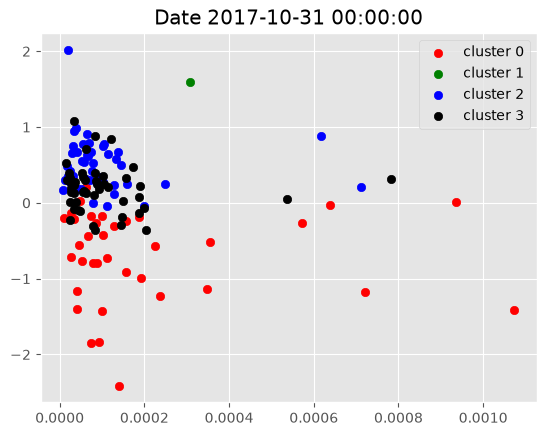

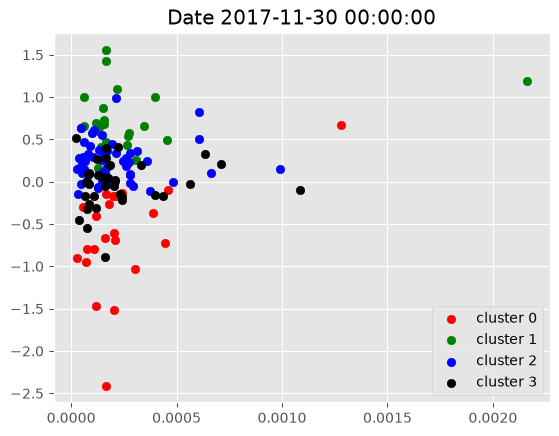

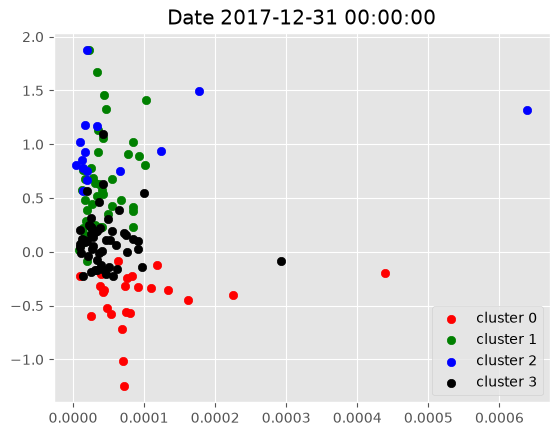

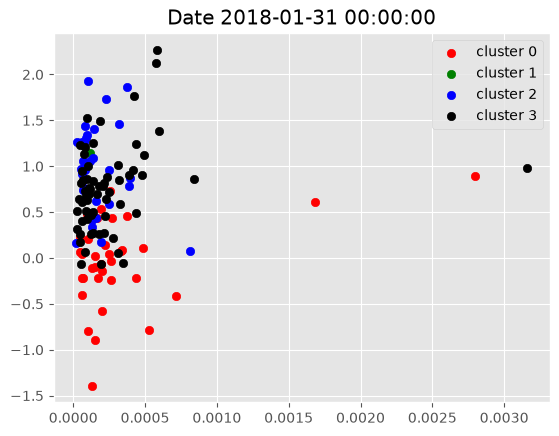

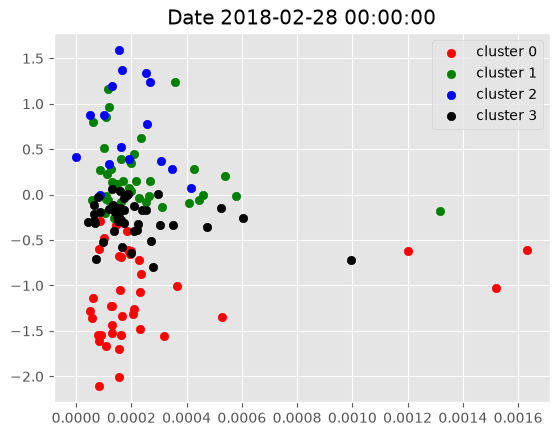

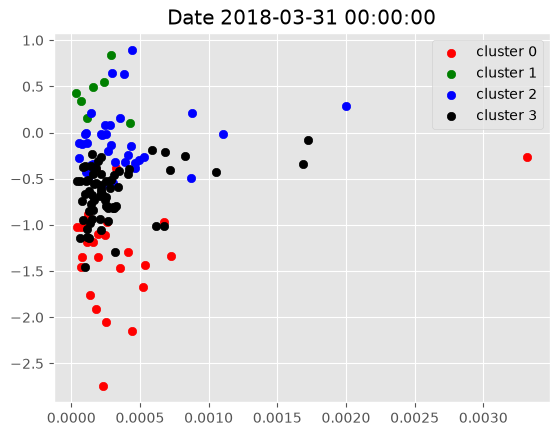

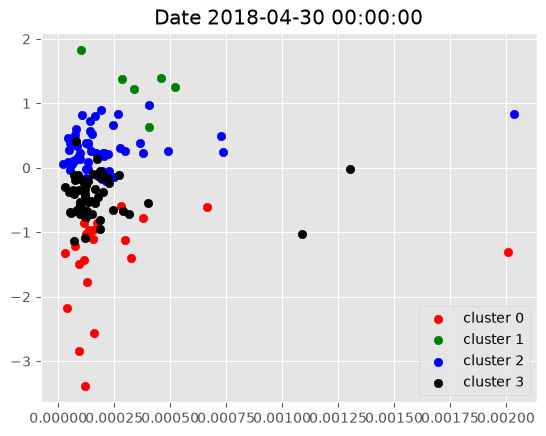

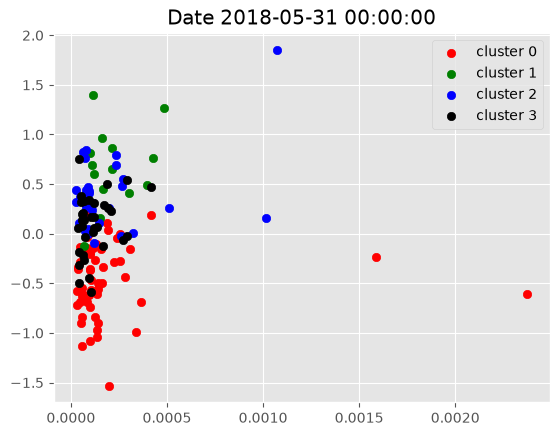

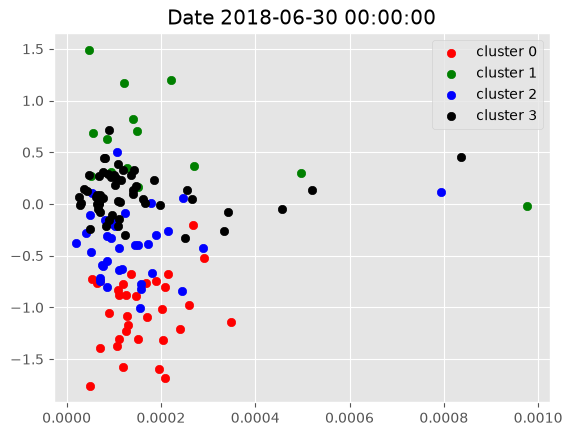

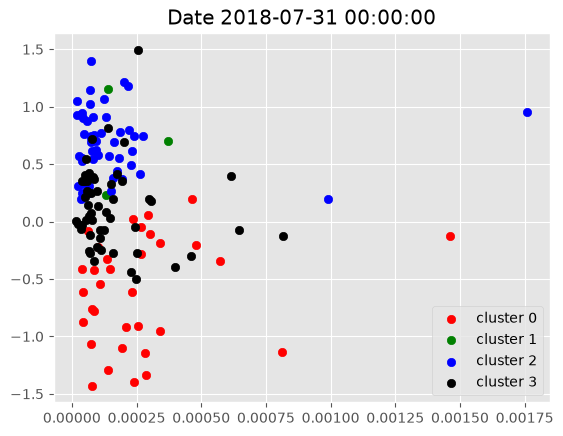

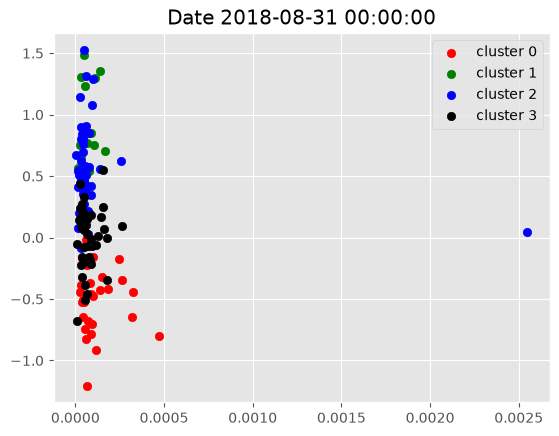

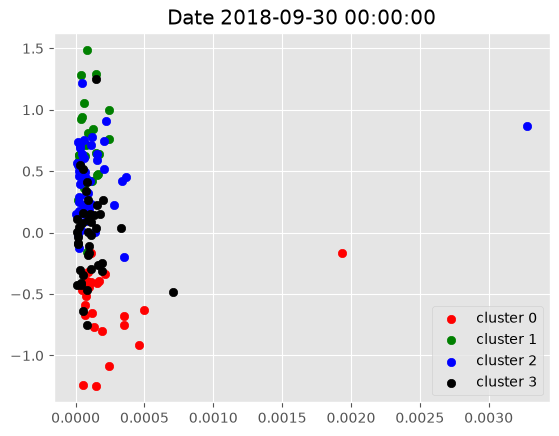

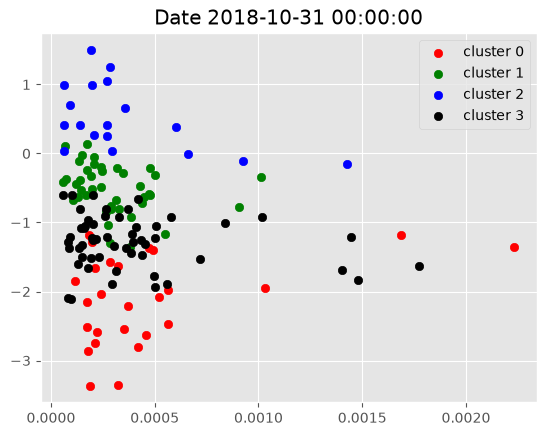

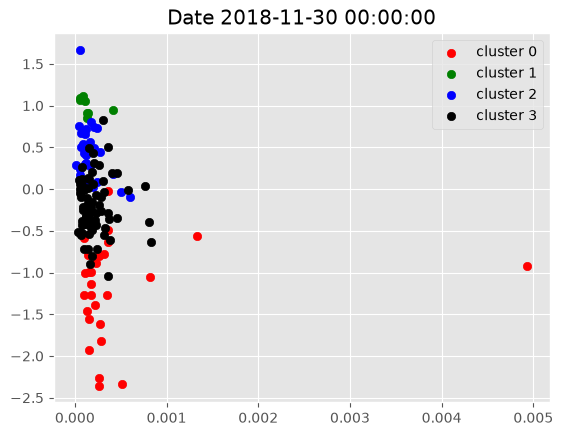

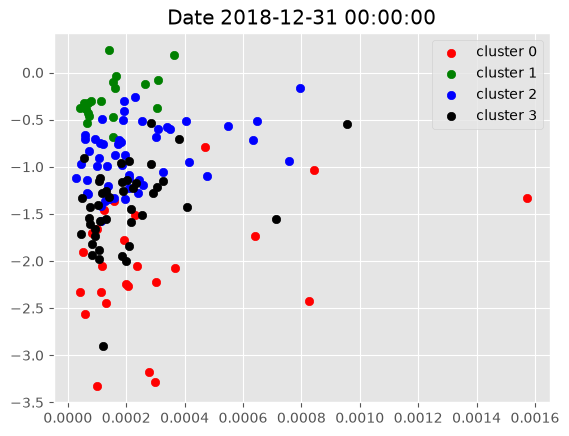

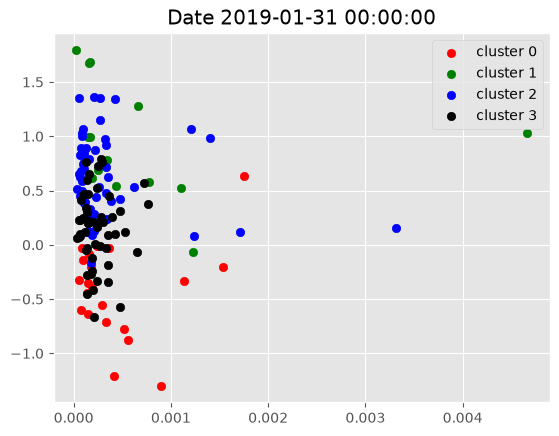

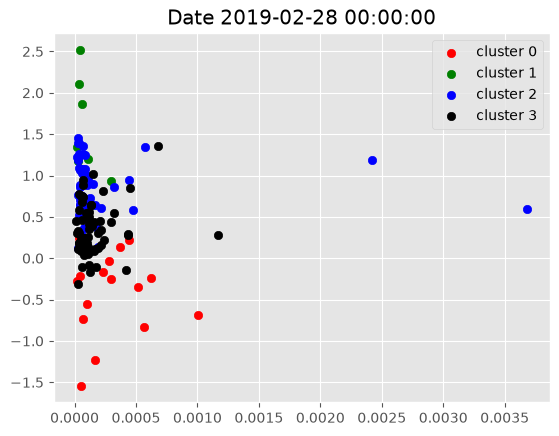

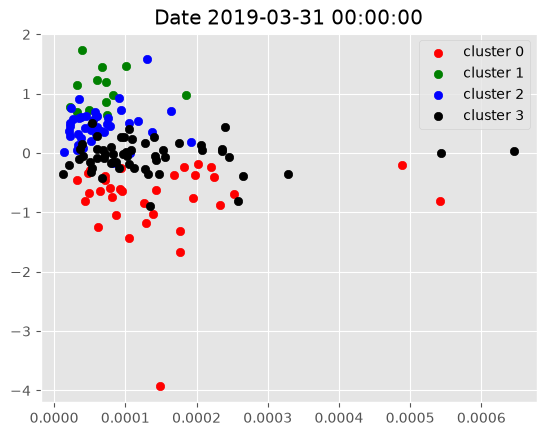

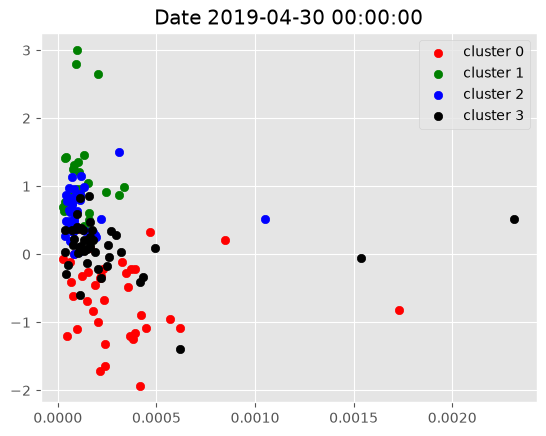

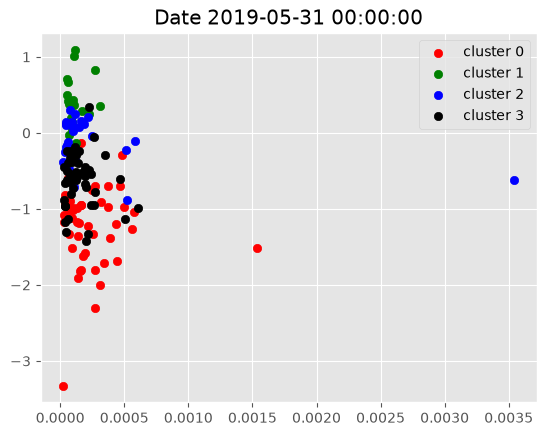

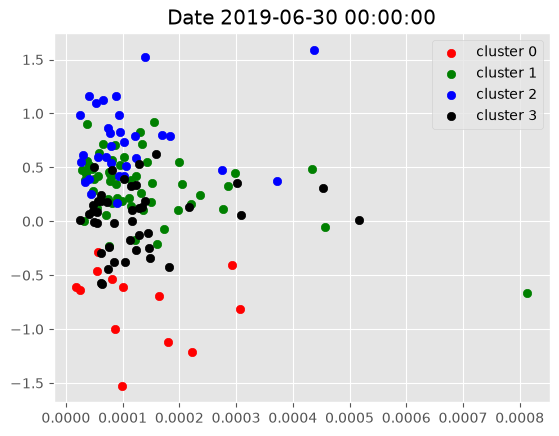

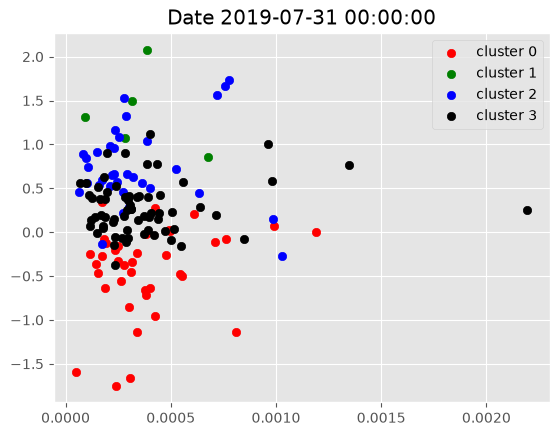

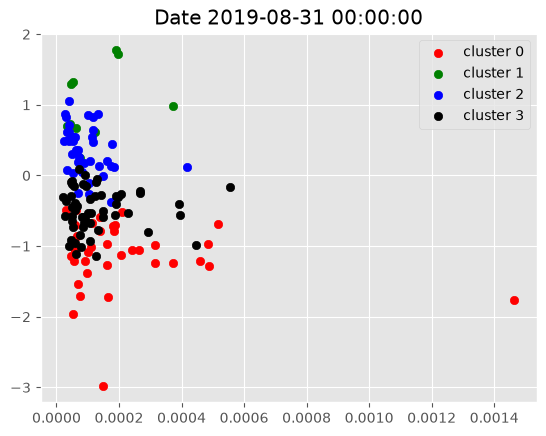

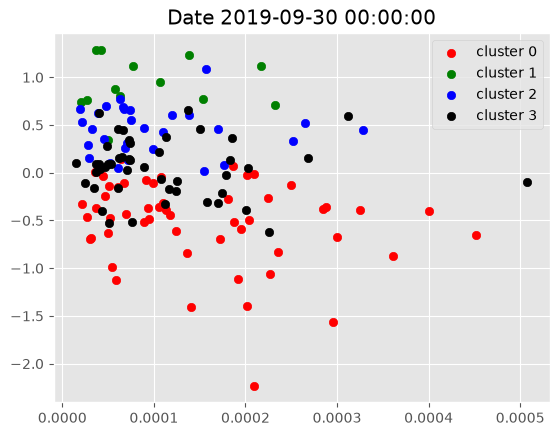

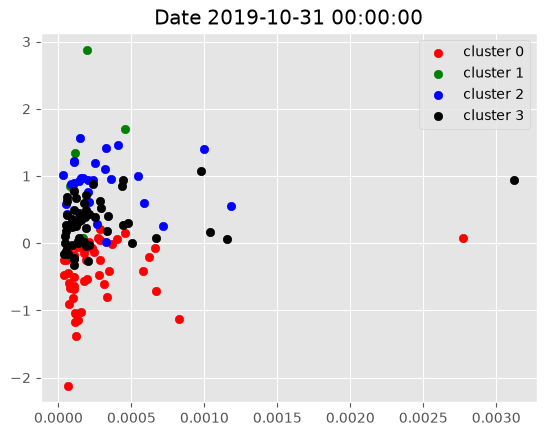

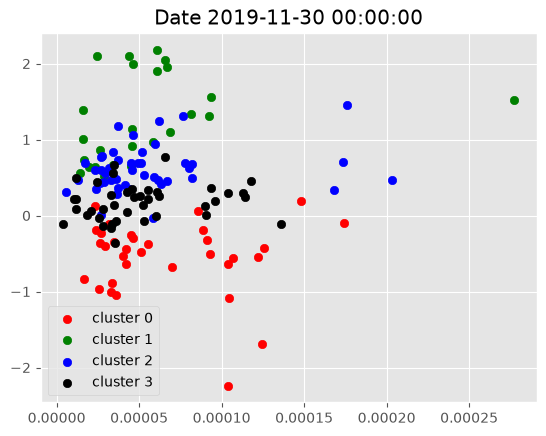

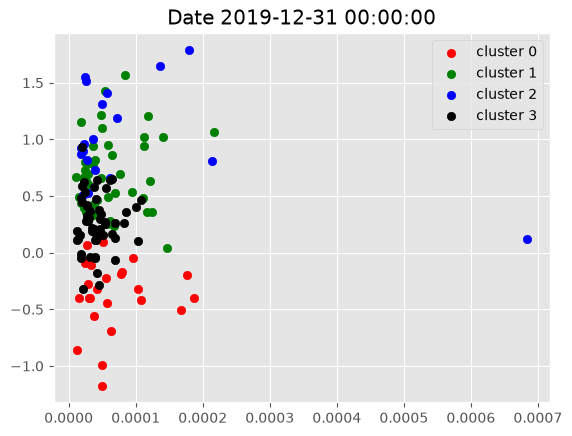

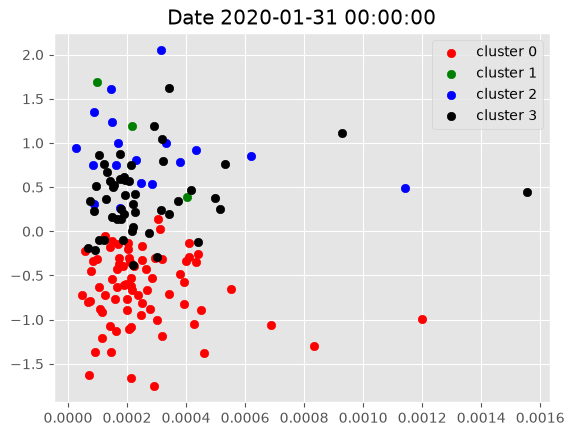

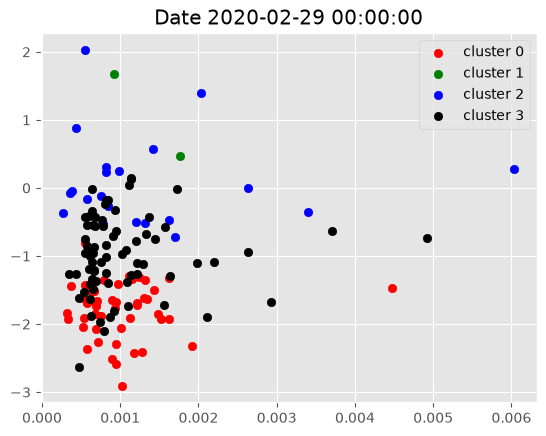

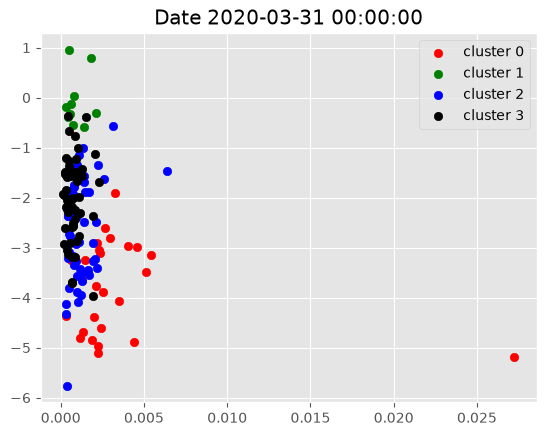

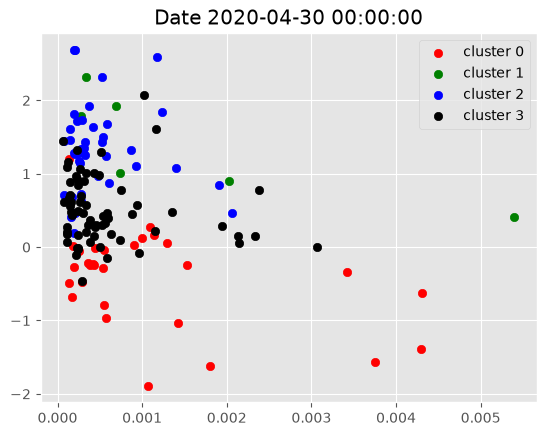

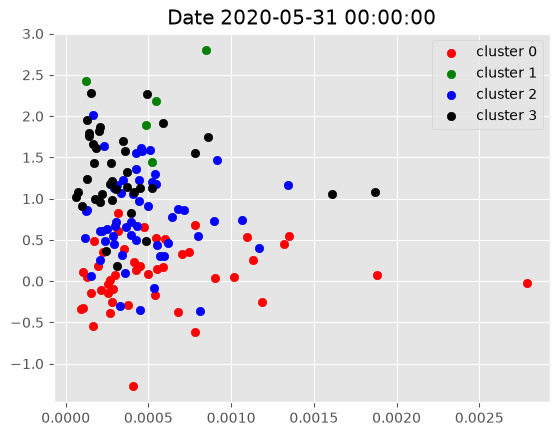

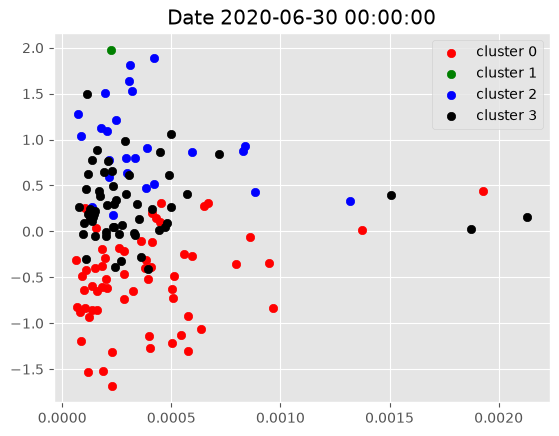

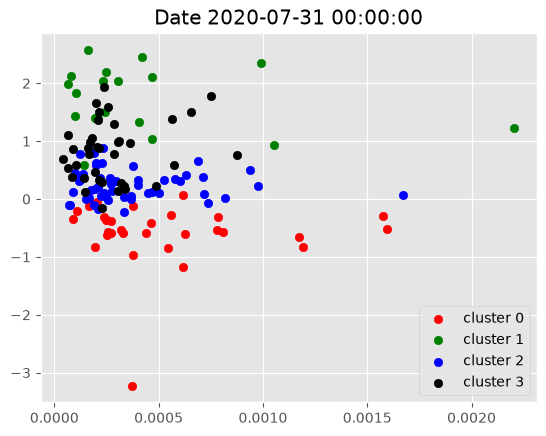

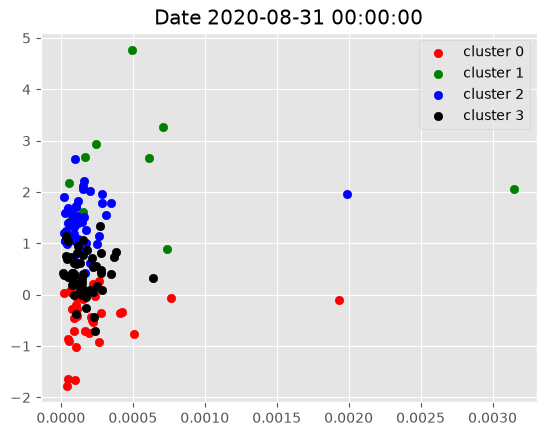

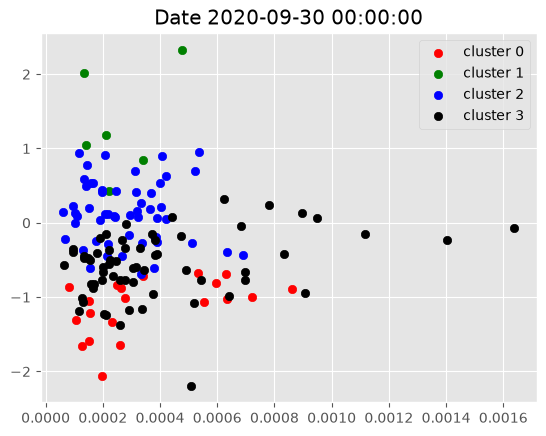

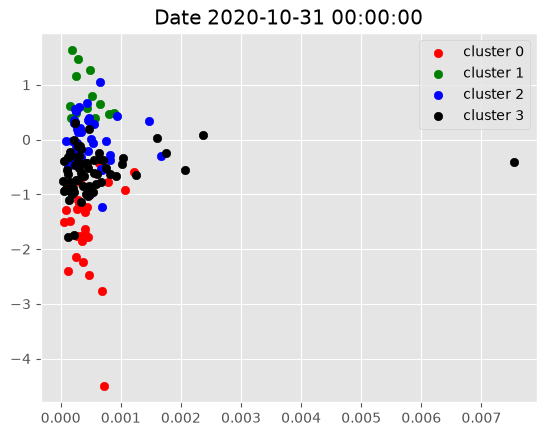

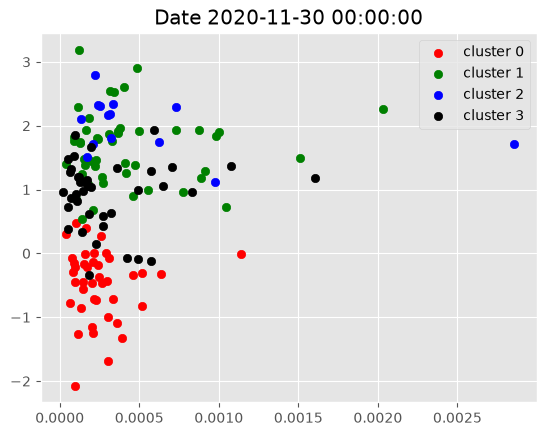

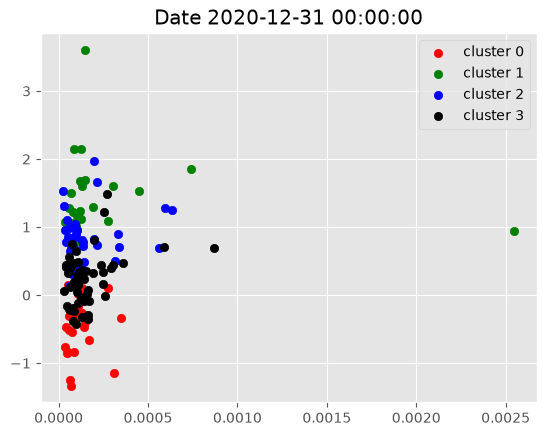

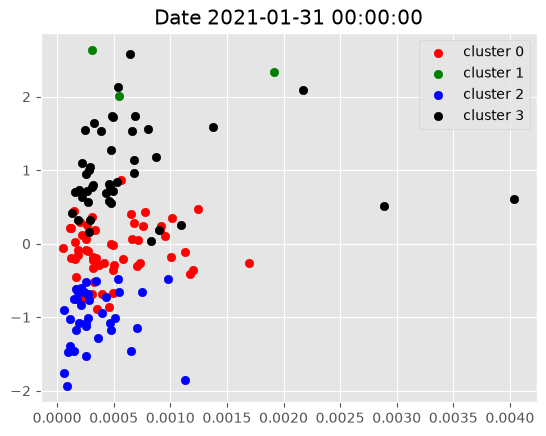

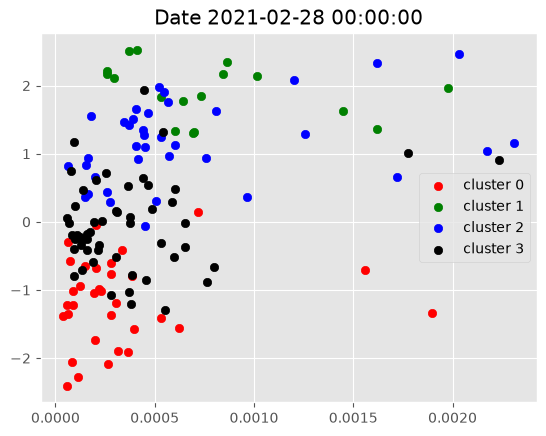

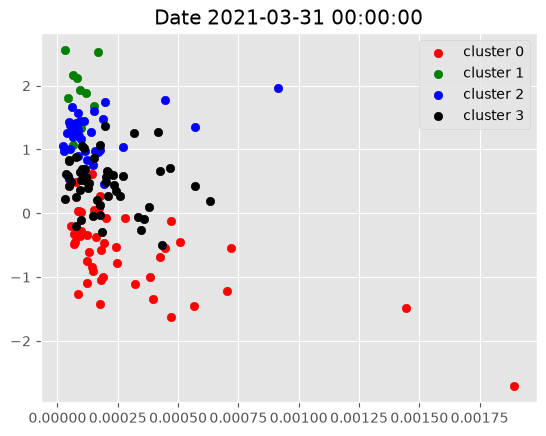

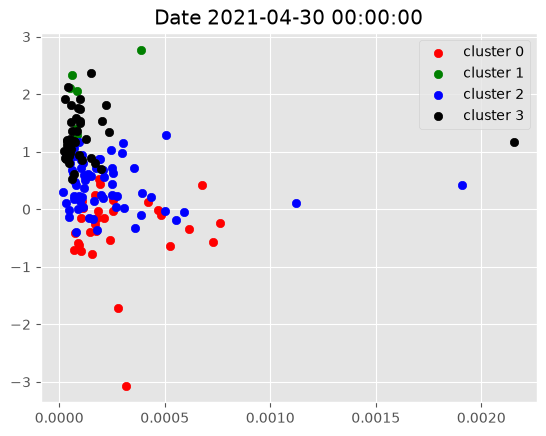

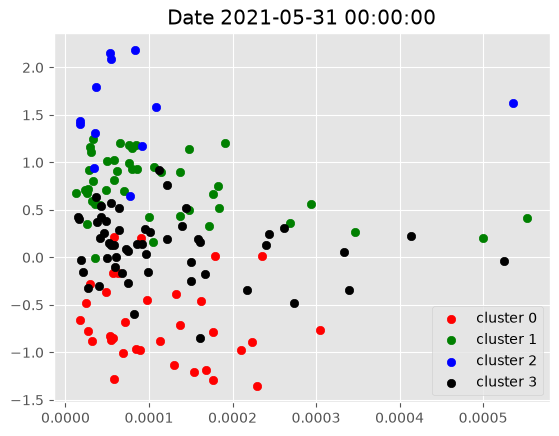

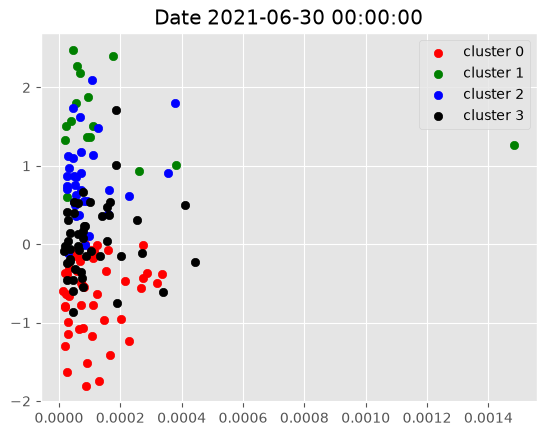

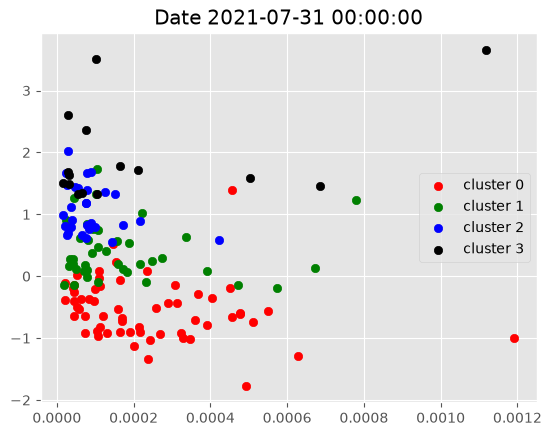

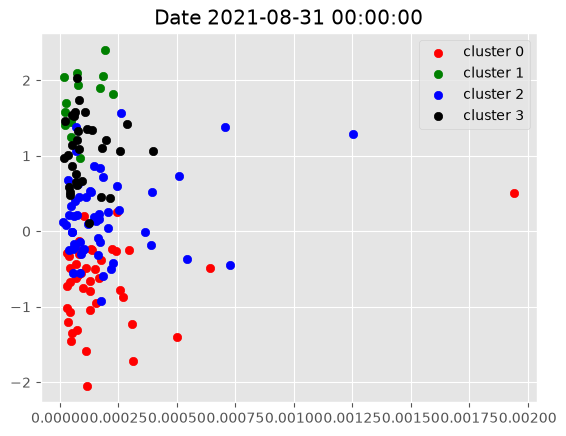

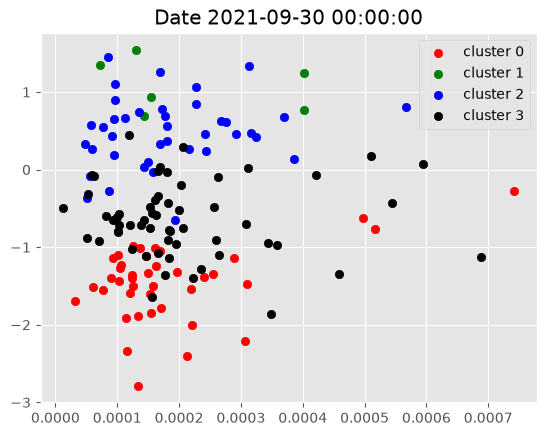

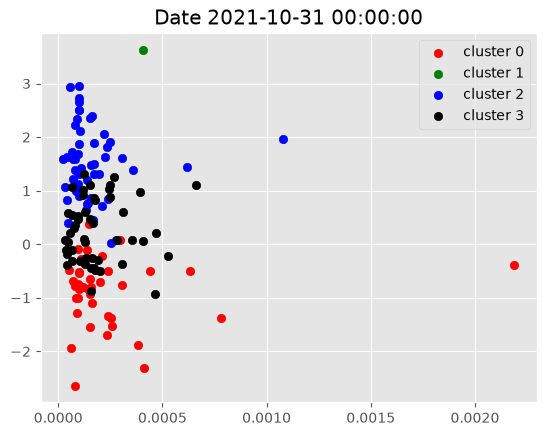

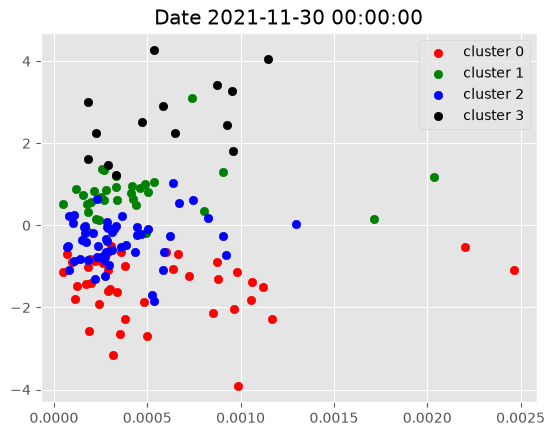

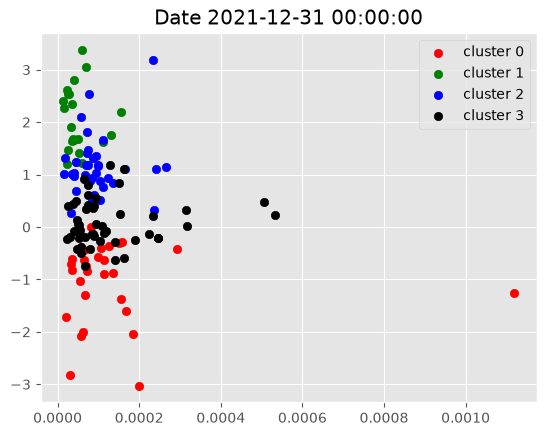

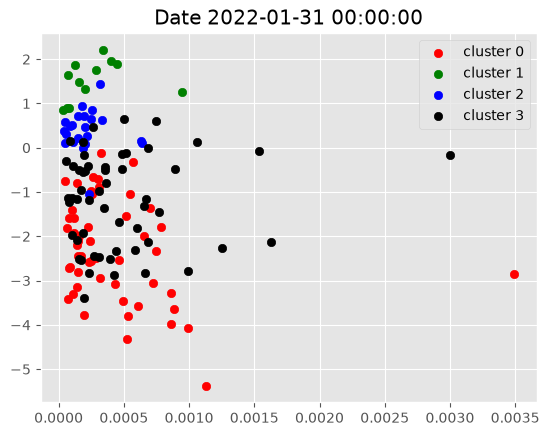

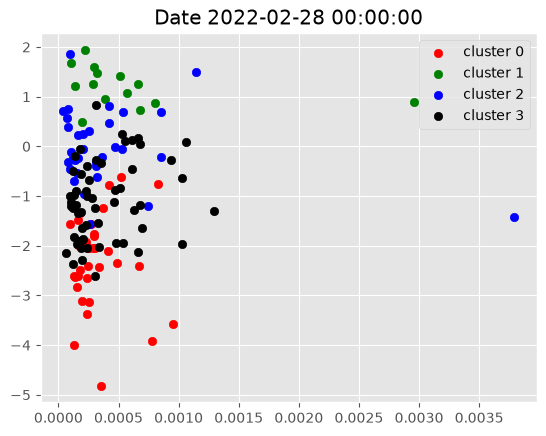

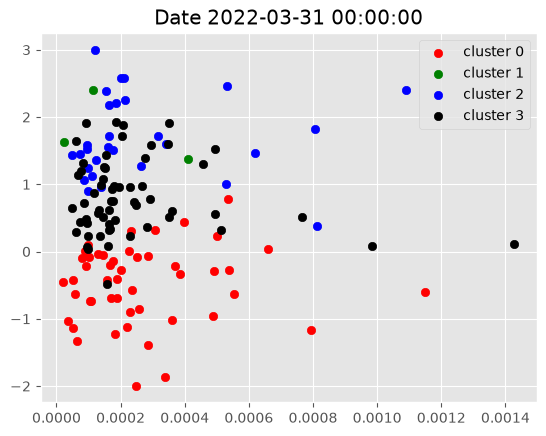

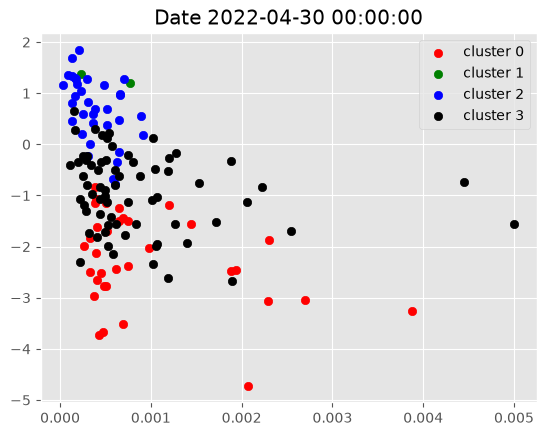

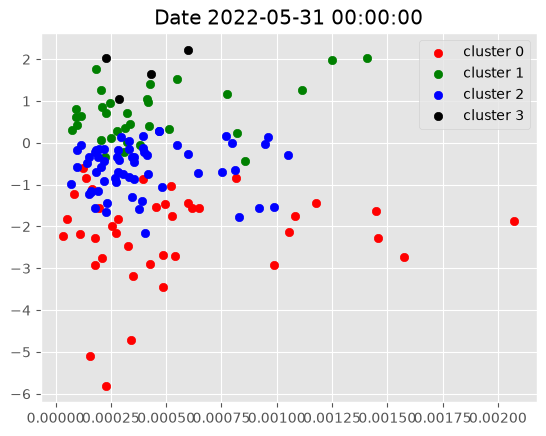

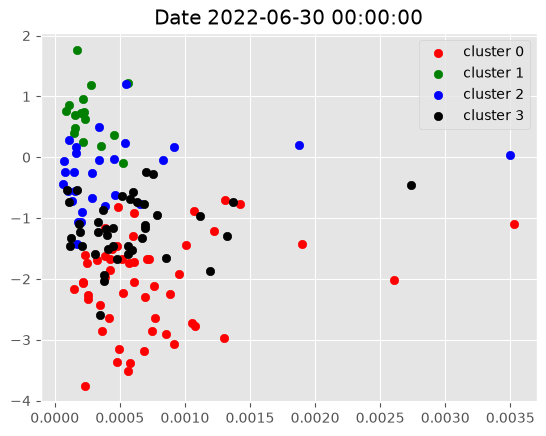

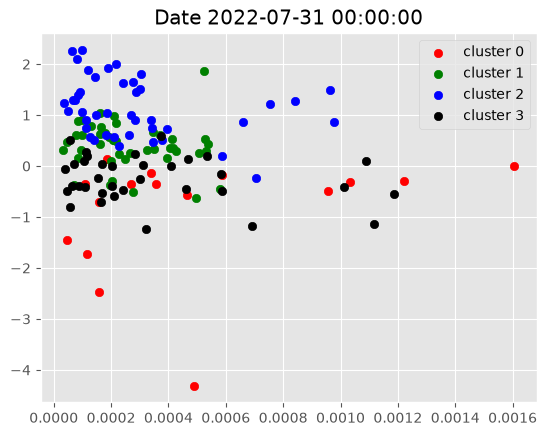

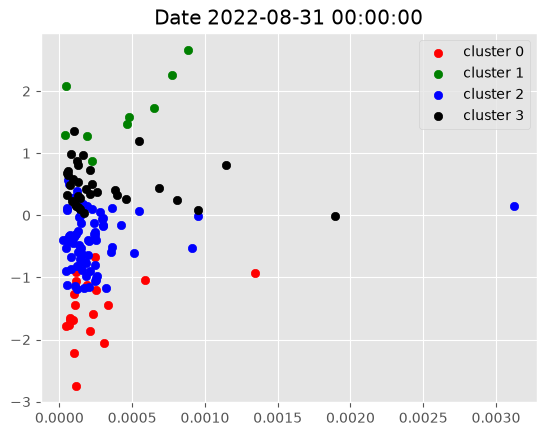

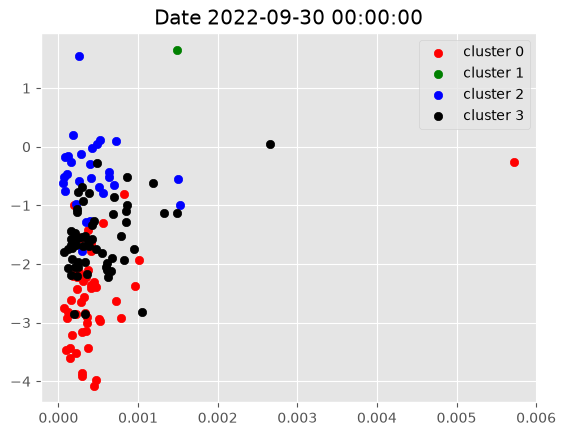

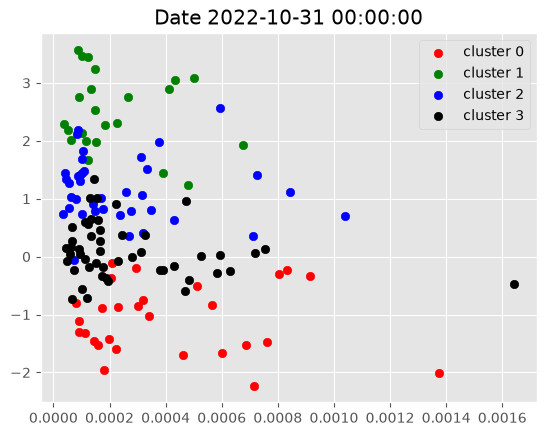

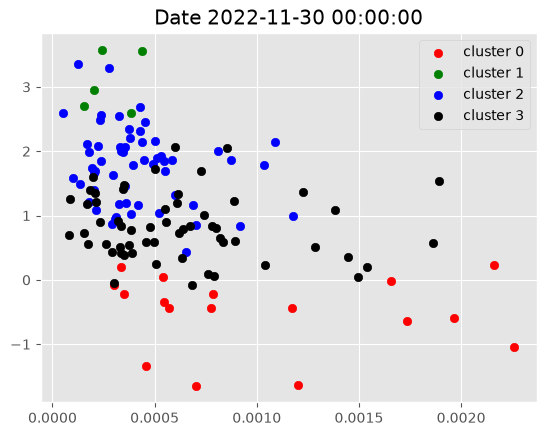

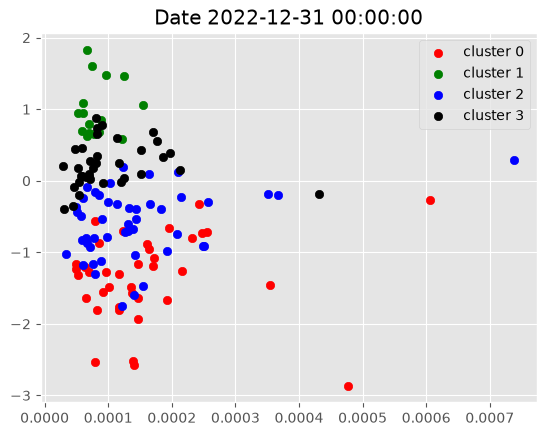

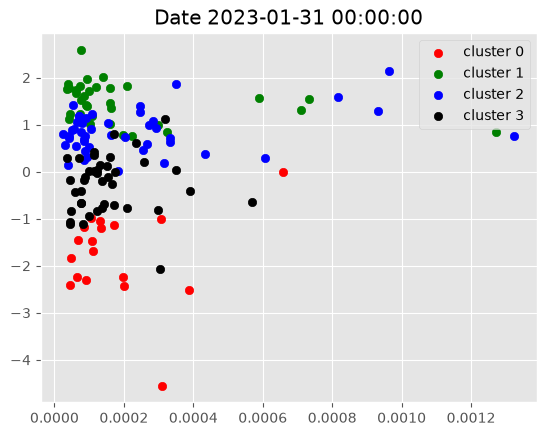

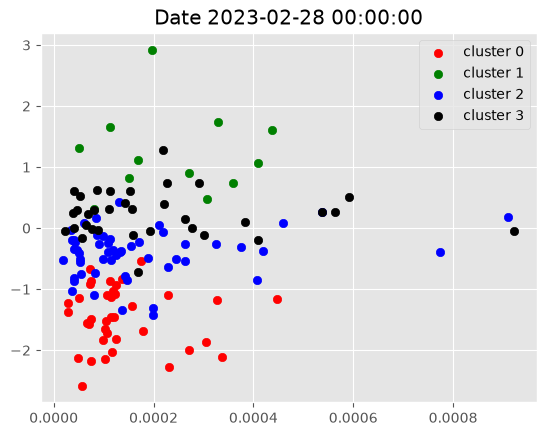

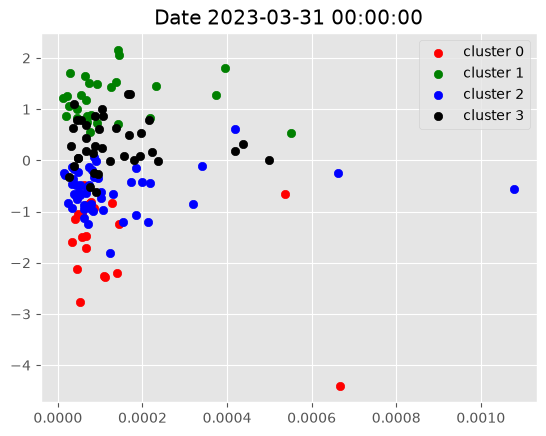

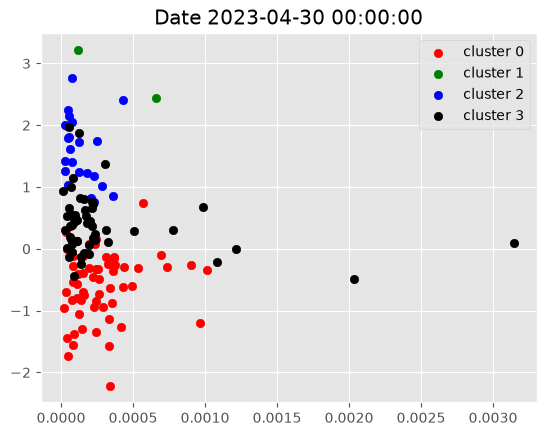

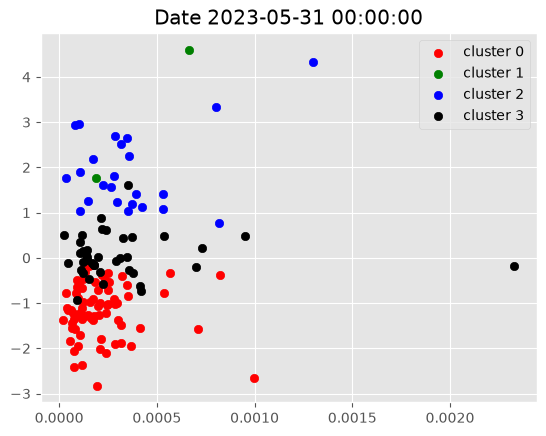

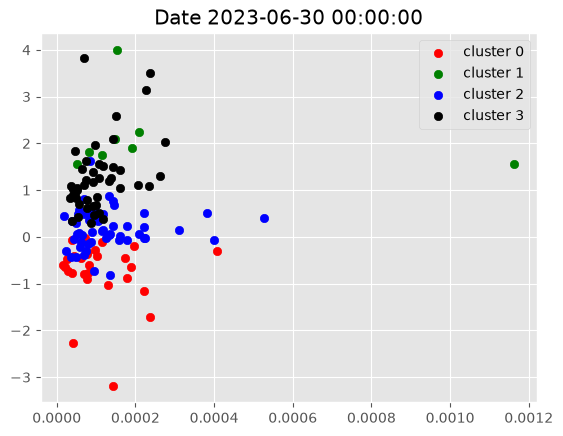

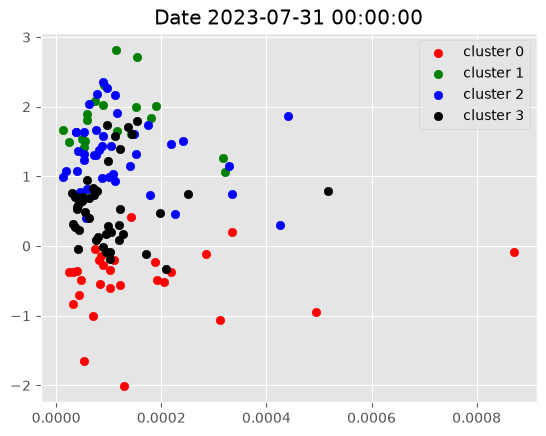

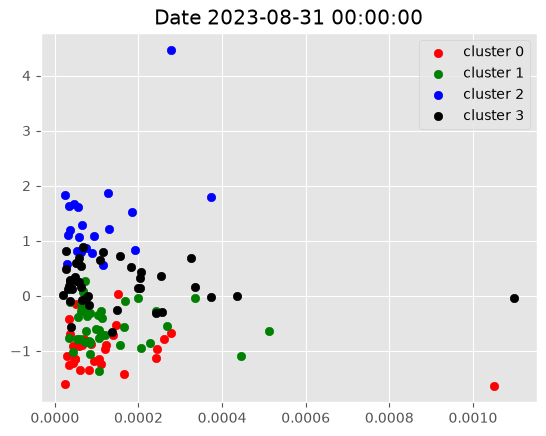

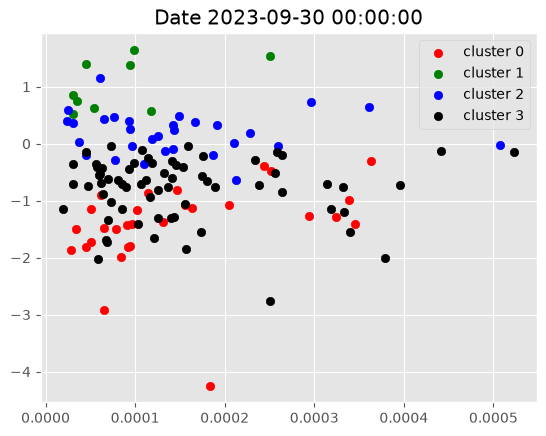

In [14]:
plt.style.use('ggplot')

for i in data.index.get_level_values('date').unique().tolist():
    
    g = data.xs(i, level=0)
    
    plt.title(f'Date {i}')
    
    plot_clusters(g)

## 7. For each month select assets based on the cluster and form a portfolio based on 

- Efficient Frontier max sharpe ratio optimization
First we will filter only stocks corresponding to the cluster we choose based on our hypothesis.

- Momentum is persistent and my idea would be that stocks clustered around RSI 70 centroid should continue to outperform in the following month - thus I would select stocks corresponding to cluster 3.

In [15]:
filtered_df = data[data['cluster']==3].copy()

filtered_df = filtered_df.reset_index(level=1)

filtered_df.index = filtered_df.index+pd.DateOffset(1)

filtered_df = filtered_df.reset_index().set_index(['date', 'ticker'])

dates = filtered_df.index.get_level_values('date').unique().tolist()

fixed_dates = {}

for d in dates:
    
    fixed_dates[d.strftime('%Y-%m-%d')] = filtered_df.xs(d, level=0).index.tolist()
    
fixed_dates

{'2017-11-01': ['ABBV',
  'ABT',
  'AZO',
  'BA',
  'BKNG',
  'BMY',
  'BRK-B',
  'C',
  'CCL',
  'COST',
  'CSCO',
  'CVX',
  'DD',
  'DG',
  'EBAY',
  'F',
  'FDX',
  'GM',
  'GS',
  'HAL',
  'HD',
  'HON',
  'HUM',
  'IBM',
  'ILMN',
  'JNJ',
  'KO',
  'LOW',
  'MDLZ',
  'MDT',
  'MO',
  'MS',
  'NFLX',
  'NKE',
  'NOC',
  'ORLY',
  'OXY',
  'PANW',
  'RTX',
  'SBUX',
  'SCHW',
  'TGT',
  'TMO',
  'UNP',
  'UPS',
  'USB',
  'WDC',
  'WYNN'],
 '2017-12-01': ['AAPL',
  'AMGN',
  'BIIB',
  'BMY',
  'CCL',
  'CL',
  'CMCSA',
  'CMG',
  'COP',
  'CRM',
  'DD',
  'EOG',
  'GD',
  'GILD',
  'GM',
  'GOOG',
  'GOOGL',
  'JNJ',
  'KO',
  'LLY',
  'MA',
  'MCK',
  'MDT',
  'META',
  'NVDA',
  'ORCL',
  'PANW',
  'PG',
  'PYPL',
  'STZ',
  'TGT',
  'TMO',
  'TXN',
  'ULTA',
  'V'],
 '2018-01-01': ['ABBV',
  'ADBE',
  'AMZN',
  'BIIB',
  'C',
  'CCL',
  'CHTR',
  'CMCSA',
  'CSX',
  'CVS',
  'DD',
  'DHR',
  'DIS',
  'EBAY',
  'ELV',
  'F',
  'GD',
  'GOOG',
  'GOOGL',
  'GS',
  'HON',
  'HUM',

## Define portfolio optimization function

- We will define a function which optimizes portfolio weights using PyPortfolioOpt package and EfficientFrontier optimizer to maximize the sharpe ratio.

- To optimize the weights of a given portfolio we would need to supply last 1 year prices to the function.

- Apply signle stock weight bounds constraint for diversification (minimum half of equaly weight and maximum 10% of portfolio).

In [16]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

def optimize_weights(prices, lower_bound=0):
    
    returns = expected_returns.mean_historical_return(prices=prices,
                                                      frequency=252)
    
    cov = risk_models.sample_cov(prices=prices,
                                 frequency=252)
    
    ef = EfficientFrontier(expected_returns=returns,
                           cov_matrix=cov,
                           weight_bounds=(lower_bound, .1),
                           solver='SCS')
    
    weights = ef.max_sharpe()
    
    return ef.clean_weights()

- Download Fresh Daily Prices Data only for short listed stocks.

In [17]:
stocks = data.index.get_level_values('ticker').unique().tolist()

new_df = yf.download(tickers=stocks,
                     start=data.index.get_level_values('date').unique()[0]-pd.DateOffset(months=12),
                     end=data.index.get_level_values('date').unique()[-1])

new_df

[*********************100%***********************]  156 of 156 completed


Price            Close                                                 \
Ticker            AAPL        ABBV        ABT         ACN        ADBE   
Date                                                                    
2016-10-31   25.964973   37.343330  32.713142   99.209396  107.510002   
2016-11-01   25.496153   37.791866  32.554729   99.124062  106.870003   
2016-11-02   25.519026   38.019501  32.262947  101.232170  105.889999   
2016-11-03   25.245499   37.416969  31.996178   99.815384  107.169998   
2016-11-04   25.017925   37.517395  32.588078  100.054344  106.199997   
...                ...         ...        ...         ...         ...   
2023-09-25  173.730301  139.430420  91.567818  300.128418  511.600006   
2023-09-26  169.665283  138.763229  90.402893  294.087769  506.299988   
2023-09-27  168.155655  138.060013  89.745285  297.657257  502.600006   
2023-09-28  168.412216  137.266602  92.178452  284.771210  504.670013   
2023-09-29  168.925262  134.390533  90.985344  290.773956  509.899994   

Price                                                                  ...  \
Ticker             ADP        ADSK        AIG        AMAT         AMD  ...   
Date                                                                   ...   
2016-10-31   69.929512   72.279999  47.940224   26.137413    7.230000  ...   
2016-11-01   69.817055   70.099998  47.147694   25.975620    7.090000  ...   
2016-11-02   72.274948   68.680000  47.046688   25.696999    6.760000  ...   
2016-11-03   71.752831   67.610001  45.181904   25.409374    6.700000  ...   
2016-11-04   71.552040   69.440002  44.583641   25.364429    6.560000  ...   
...                ...         ...        ...         ...         ...  ...   
2023-09-25  223.379623  205.669998  58.113834  133.425217   97.379997  ...   
2023-09-26  220.792343  201.660004  57.300076  130.973358   95.959999  ...   
2023-09-27  225.808716  202.279999  57.066235  131.930634   98.070000  ...   
2023-09-28  226.441544  207.889999  57.318775  135.017456  102.760002  ...   
2023-09-29  223.900803  206.910004  56.682735  135.242126  102.820000  ...   

Price        Volume                                                           \
Ticker          VLO     VRTX        VZ     WDAY      WDC       WFC       WMT   
Date                                                                           
2016-10-31  4969500  1928200  12459400  1147300  4449514  20115900  19167000   
2016-11-01  7816800  2458200  13229400  1091400  5055315  20020200  26515800   
2016-11-02  7317600  2580400  16488200  1127800  5578033  19566600  22935900   
2016-11-03  3855900  2371000  12605100   633300  4223810  14982700  20411700   
2016-11-04  3729900  1902100  14410200   892600  3579509  27391600  21786300   
...             ...      ...       ...      ...      ...       ...       ...   
2023-09-25  3241900   698100  17616900   894200  3553446  10624000  10459500   
2023-09-26  4936800   633600  18841600  1217300  4724565  15219400  14435700   
2023-09-27  3644000   860600  22083500  2338100  3370739  11815500  15711000   
2023-09-28  3587300   578900  18772100  9196300  4342086  12454600  11617200   
2023-09-29  4302200   896800  19787600  4066600  3323376  13124500  18842400   

Price                                    
Ticker         WYNN       XOM       XYZ  
Date                                     
2016-10-31  1341600  16663800   2960600  
2016-11-01  3722300  13050600   8190900  
2016-11-02  2542400  11226100  19503200  
2016-11-03  9050400   8836500   7371500  
2016-11-04  3223800  13877100  13462800  
...             ...       ...       ...  
2023-09-25  1387800  11316000   8841300  
2023-09-26  1454000  11805400  10168200  
2023-09-27  2050000  23976200  11656100  
2023-09-28  1290400  16808100  16585100  
2023-09-29  1326800  18813600  11965300  

[1740 rows x 780 columns]

- Calculate daily returns for each stock which could land up in our portfolio.

- Then loop over each month start, select the stocks for the month and calculate their weights for the next month.

- If the maximum sharpe ratio optimization fails for a given month, apply equally-weighted weights.

- Calculated each day portfolio return.

In [18]:
price_col = 'Adj Close' if 'Adj Close' in new_df.columns else 'Close'
returns_dataframe = np.log(new_df[price_col]).diff()
returns_dataframe.index.name = 'Date'
returns_dataframe.columns.name = 'ticker'

portfolio_df = pd.DataFrame()

for start_date in fixed_dates.keys():

    try:

        end_date = (pd.to_datetime(start_date)+pd.offsets.MonthEnd(0)).strftime('%Y-%m-%d')

        cols = fixed_dates[start_date]

        optimization_start_date = (pd.to_datetime(start_date)-pd.DateOffset(months=12)).strftime('%Y-%m-%d')

        optimization_end_date = (pd.to_datetime(start_date)-pd.DateOffset(days=1)).strftime('%Y-%m-%d')

        optimization_df = new_df[optimization_start_date:optimization_end_date][price_col][cols]

        success = False
        try:
            weights = optimize_weights(prices=optimization_df,
                                   lower_bound=round(1/(len(optimization_df.columns)*2),3))

            weights = pd.DataFrame(weights, index=pd.Series(0))

            success = True
        except:
            print(f'Max Sharpe Optimization failed for {start_date}, Continuing with Equal-Weights')

        if success==False:
            weights = pd.DataFrame([1/len(optimization_df.columns) for i in range(len(optimization_df.columns))],
                                     index=optimization_df.columns.tolist(),
                                     columns=pd.Series(0)).T

        weights.columns.name = 'ticker'

        temp_df = returns_dataframe[start_date:end_date]

        temp_df = temp_df.stack().to_frame('return').reset_index(level=0)\
                   .merge(weights.stack().to_frame('weight').reset_index(level=0, drop=True),
                          left_index=True,
                          right_index=True)\
                   .reset_index().set_index(['Date', 'ticker']).unstack().stack()

        temp_df.index.names = ['date', 'ticker']

        temp_df['weighted_return'] = temp_df['return']*temp_df['weight']

        temp_df = temp_df.groupby(level=0)['weighted_return'].sum().to_frame('Strategy Return')

        portfolio_df = pd.concat([portfolio_df, temp_df], axis=0)

    except Exception as e:
        print(e)

portfolio_df = portfolio_df.drop_duplicates()

portfolio_df


Max Sharpe Optimization failed for 2022-06-01, Continuing with Equal-Weights
'return'


,Strategy Return
date,
2017-11-01,0.003261
2017-11-02,0.000728
2017-11-03,0.003355
2017-11-06,-0.000810
2017-11-07,-0.000229
...,...
2023-09-25,0.005195
2023-09-26,-0.016372
2023-09-27,0.004806


## 8. Visualize Portfolio returns and compare to SP500 returns.


In [19]:
spy = yf.download(tickers='SPY',
                  start='2015-01-01',
                  end=dt.date.today())

if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

spy_price_col = 'Adj Close' if 'Adj Close' in spy.columns else 'Close'

spy_ret = np.log(spy[[spy_price_col]]).diff().dropna().rename({spy_price_col: 'SPY Buy&Hold'}, axis=1)

portfolio_df = portfolio_df.merge(spy_ret,
                                  left_index=True,
                                  right_index=True)

portfolio_df


[*********************100%***********************]  1 of 1 completed


,Strategy Return,SPY Buy&Hold
date,,
2017-11-01,0.003261,0.001321
2017-11-02,0.000728,0.000388
2017-11-03,0.003355,0.003333
2017-11-06,-0.000810,0.001546
2017-11-07,-0.000229,-0.000696
...,...,...
2023-09-25,0.005195,0.004197
2023-09-26,-0.016372,-0.014800
2023-09-27,0.004806,0.000399


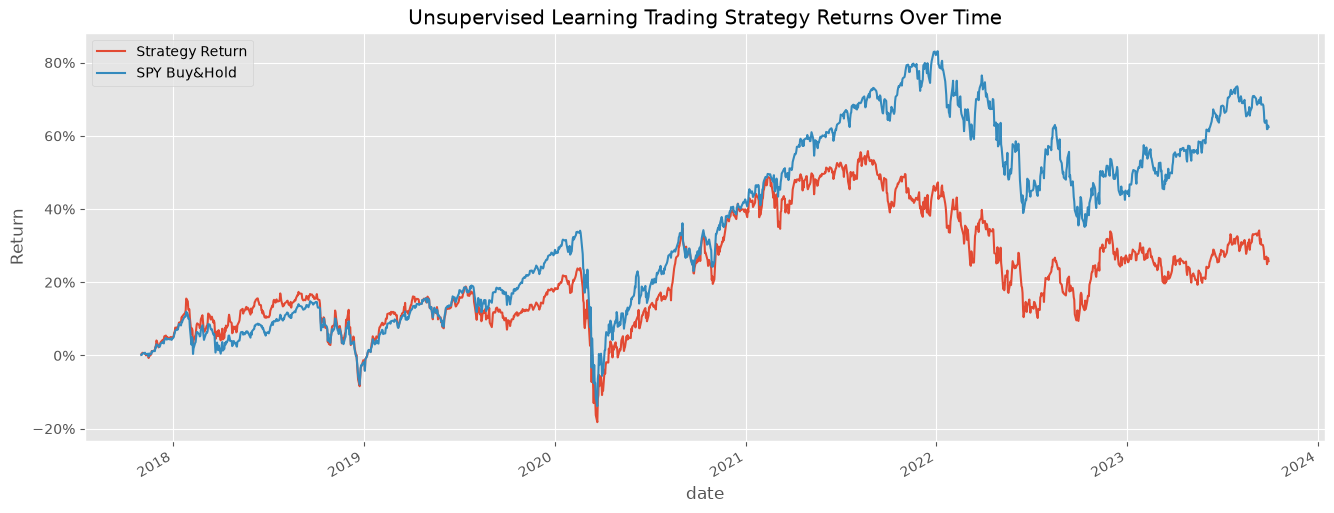

In [20]:
import matplotlib.ticker as mtick

plt.style.use('ggplot')

portfolio_cumulative_return = np.exp(np.log1p(portfolio_df).cumsum())-1

portfolio_cumulative_return[:'2023-09-29'].plot(figsize=(16,6))

plt.title('Unsupervised Learning Trading Strategy Returns Over Time')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel('Return')

plt.show()
